In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# Load model and data
xgb = joblib.load('xgb_churn_model.pkl')
X_train, X_test, y_train, y_test = joblib.load('processed_data.pkl')

print(f"Model loaded ✅")
print(f"Test set: {X_test.shape}")

Model loaded ✅
Test set: (1409, 40)


In [2]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP explainer ready ✅")

SHAP values shape: (1409, 40)
SHAP explainer ready ✅


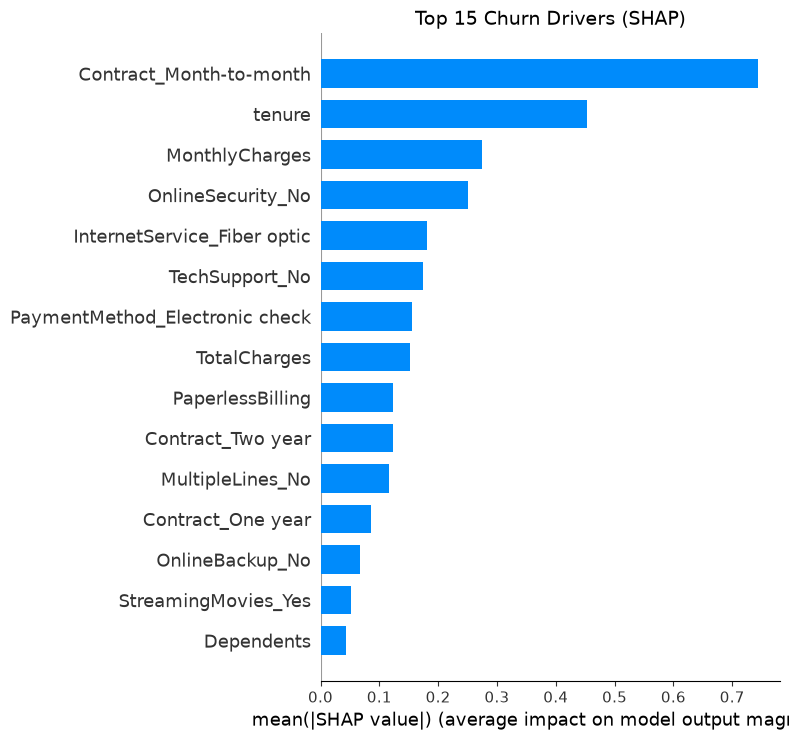

Saved: shap_importance.png ✅


In [3]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Top 15 Churn Drivers (SHAP)", fontsize=14)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_importance.png ✅")

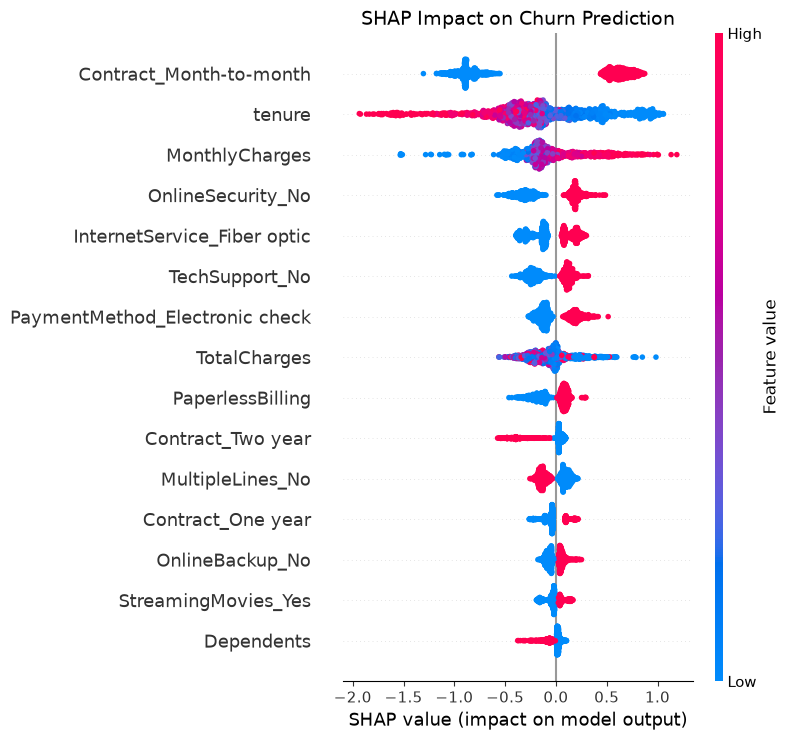

In [4]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test,
    max_display=15,
    show=False
)
plt.title("SHAP Impact on Churn Prediction", fontsize=14)
plt.tight_layout()
plt.savefig('shap_dot_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Mean absolute SHAP value per feature
shap_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False).head(10).reset_index(drop=True)

shap_df['Rank'] = shap_df.index + 1
print(shap_df[['Rank', 'Feature', 'Mean_SHAP']].to_string(index=False))

 Rank                        Feature  Mean_SHAP
    1        Contract_Month-to-month   0.743986
    2                         tenure   0.453019
    3                 MonthlyCharges   0.273948
    4              OnlineSecurity_No   0.250865
    5    InternetService_Fiber optic   0.181500
    6                 TechSupport_No   0.174312
    7 PaymentMethod_Electronic check   0.156112
    8                   TotalCharges   0.152912
    9               PaperlessBilling   0.123462
   10              Contract_Two year   0.123179


In [6]:
print("=" * 55)
print("CONSULTING INSIGHTS FROM SHAP ANALYSIS")
print("=" * 55)

insights = [
    {
        "rank": 1,
        "driver": "Contract Type (Month-to-Month)",
        "finding": "Strongest single predictor of churn",
        "recommendation": "Incentivize annual contracts with 10–15% discount or loyalty perks"
    },
    {
        "rank": 2,
        "driver": "Tenure (How long they've been a customer)",
        "finding": "Low tenure = high churn risk; risk drops sharply after 12 months",
        "recommendation": "Launch a 90-day onboarding program with proactive check-ins for new customers"
    },
    {
        "rank": 3,
        "driver": "Monthly Charges",
        "finding": "High-paying customers on flexible plans churn most",
        "recommendation": "Offer personalised retention packages to customers paying above $65/mo on month-to-month plans"
    }
]

for i in insights:
    print(f"\n📌 Insight #{i['rank']}: {i['driver']}")
    print(f"   Finding        : {i['finding']}")
    print(f"   Recommendation : {i['recommendation']}")

print("\n" + "=" * 55)

CONSULTING INSIGHTS FROM SHAP ANALYSIS

📌 Insight #1: Contract Type (Month-to-Month)
   Finding        : Strongest single predictor of churn
   Recommendation : Incentivize annual contracts with 10–15% discount or loyalty perks

📌 Insight #2: Tenure (How long they've been a customer)
   Finding        : Low tenure = high churn risk; risk drops sharply after 12 months
   Recommendation : Launch a 90-day onboarding program with proactive check-ins for new customers

📌 Insight #3: Monthly Charges
   Finding        : High-paying customers on flexible plans churn most
   Recommendation : Offer personalised retention packages to customers paying above $65/mo on month-to-month plans



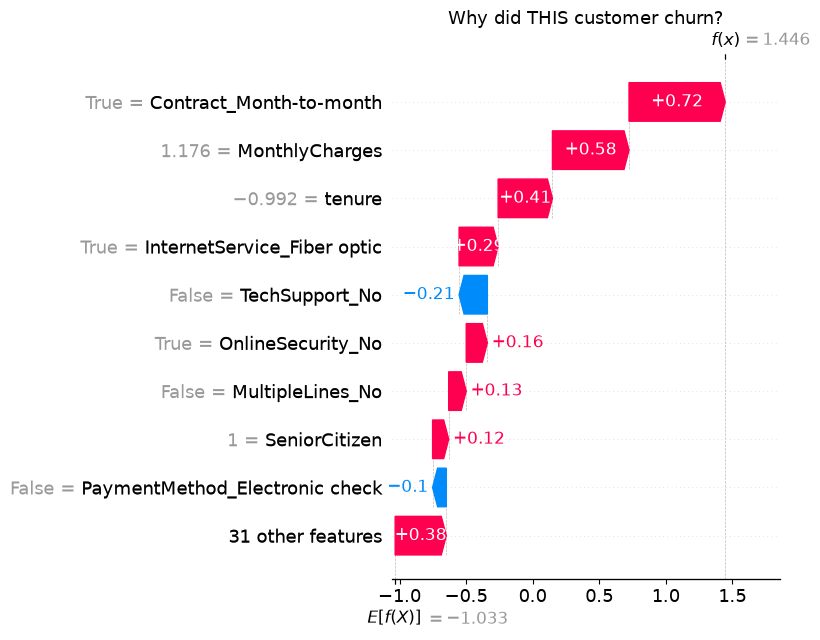

In [7]:
# Pick a customer the model predicted would churn
churn_indices = np.where(xgb.predict(X_test) == 1)[0]
sample_idx = churn_indices[0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_idx],
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.title("Why did THIS customer churn?", fontsize=13)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
joblib.dump(shap_values, 'shap_values.pkl')
joblib.dump(explainer, 'shap_explainer.pkl')

print("SHAP values saved ✅")
print("SHAP explainer saved ✅")
print("\n→ Ready for Phase 5: Dashboard & Consulting Brief 🚀")

SHAP values saved ✅
SHAP explainer saved ✅

→ Ready for Phase 5: Dashboard & Consulting Brief 🚀
